# 02 · Strategy Implementation Verification

**Project:** CVaR Portfolio Backtest — Malta Accessible ETFs  
**Purpose:** Verify that `equal_weight`, `minimum_variance`, and `cvar_minimise` produce
correct, constraint-satisfying allocations on sample windows from the historical return data.

**Strategies tested:**

| ID | Strategy | Method |
|----|----------|--------|
| EW | Equal Weight | 1/N |
| MV | Minimum Variance | scipy SLSQP |
| CV95 | CVaR-Minimise α=0.95 | CVXPY (Rockafellar–Uryasev LP) |
| CV99 | CVaR-Minimise α=0.99 | CVXPY (Rockafellar–Uryasev LP) |

**Windows tested:**

| Label | Period | Rows |
|-------|--------|------|
| `first_252` | 2016-01-05 → 2017-01-04 | 252 |
| `last_504` | 2023-12-22 → 2025-12-30 | 504 |
| `last_252` | 2024-12-23 → 2025-12-30 | 252 |
| `full_history` | 2016-01-05 → 2025-12-30 | 2498 |

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make project root importable from notebooks/
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.strategies import cvar_minimise, equal_weight, minimum_variance

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})

FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

STRATEGY_COLORS = {
    "EW": "#4C72B0",
    "MV": "#DD8452",
    "CV95": "#55A868",
    "CV99": "#C44E52",
}
ETF_LABELS = {
    "ETF01": "ETF01\nS&P 500",
    "ETF02": "ETF02\nMSCI Eur",
    "ETF03": "ETF03\nMSCI Jpn",
    "ETF04": "ETF04\nMSCI EM",
    "ETF05": "ETF05\nUS Tsy",
    "ETF06": "ETF06\nEuro Bond",
}

## 1 · Load Return Data

In [2]:
returns = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "etf_returns_log.csv",
    parse_dates=["date"],
)
ASSETS = [c for c in returns.columns if c != "date"]
R      = returns[ASSETS]   # numeric-only view

print(f"Shape      : {returns.shape}")
print(f"First date : {returns['date'].iloc[0].date()}")
print(f"Last date  : {returns['date'].iloc[-1].date()}")
print(f"Assets     : {ASSETS}")
print(f"Missing    : {R.isna().sum().sum()}")

Shape      : (2498, 7)
First date : 2016-01-05
Last date  : 2025-12-30
Assets     : ['ETF01', 'ETF02', 'ETF03', 'ETF04', 'ETF05', 'ETF06']
Missing    : 0


## 2 · Define Sample Windows

In [3]:
WINDOWS: dict[str, pd.DataFrame] = {
    "first_252"    : R.iloc[:252],
    "last_504"     : R.iloc[-504:],
    "last_252"     : R.iloc[-252:],
    "full_history" : R,
}

for name, w in WINDOWS.items():
    idx = w.index
    first = returns.loc[idx[0], 'date'].date()
    last  = returns.loc[idx[-1], 'date'].date()
    print(f"  {name:<16} {len(w):>4} rows   {first} → {last}")

  first_252         252 rows   2016-01-05 → 2017-01-04
  last_504          504 rows   2023-12-22 → 2025-12-30
  last_252          252 rows   2024-12-23 → 2025-12-30
  full_history     2498 rows   2016-01-05 → 2025-12-30


## 3 · Helper Functions
Reusable within this notebook only — not added to `src/`.

In [4]:
TOL = 1e-6


def run_strategies(window: pd.DataFrame, alpha_list=(0.95, 0.99)) -> dict[str, pd.Series]:
    """Run all four strategies on a return window. Returns {label: weights Series}."""
    results: dict[str, pd.Series] = {}
    results["EW"] = equal_weight(window.columns)
    results["MV"] = minimum_variance(window)
    for a in alpha_list:
        label = f"CV{int(a*100)}"
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            results[label] = cvar_minimise(window, alpha=a)
            for w in caught:
                print(f"  [{label}] WARNING: {w.message}")
    return results


def constraint_check(weights: pd.Series, label: str) -> dict:
    """Verify long-only and fully-invested constraints; return a stats dict."""
    wsum   = weights.sum()
    wmin   = weights.min()
    wmax   = weights.max()
    n_neg  = int((weights < -TOL).sum())
    ok_sum = abs(wsum - 1.0) < TOL
    ok_lo  = n_neg == 0
    return {
        "strategy"  : label,
        "sum"       : round(wsum, 8),
        "min"       : round(wmin, 6),
        "max"       : round(wmax, 6),
        "n_negative": n_neg,
        "sum_ok"    : "\u2713" if ok_sum else "\u2717 FAIL",
        "long_only_ok": "\u2713" if ok_lo else "\u2717 FAIL",
    }


def make_comparison_table(results: dict[str, pd.Series]) -> pd.DataFrame:
    """Wide DataFrame: rows = strategies, columns = assets + summary stats."""
    rows = []
    for label, w in results.items():
        row = {a: round(float(w[a]), 4) for a in ASSETS}
        row["sum"]  = round(w.sum(), 6)
        row["max_w"] = round(w.max(), 4)
        row["HHI"]  = round(float((w**2).sum()), 4)
        row["eff_N"] = round(1.0 / float((w**2).sum()), 2)
        rows.append({"strategy": label, **row})
    return pd.DataFrame(rows).set_index("strategy")

## 4 · Strategy Results by Window

Each sub-section shows the four strategies run on one window:
weights, constraint check, and concentration statistics.

In [5]:
all_results: dict[str, dict[str, pd.Series]] = {}

for window_name, window_df in WINDOWS.items():
    print(f"\n{'='*60}")
    print(f"WINDOW: {window_name}  ({len(window_df)} rows)")
    print('='*60)

    res = run_strategies(window_df)
    all_results[window_name] = res

    # Comparison table
    tbl = make_comparison_table(res)
    print(tbl.to_string())
    print()

    # Constraint checks
    checks = pd.DataFrame([constraint_check(w, lbl) for lbl, w in res.items()])
    checks = checks.set_index("strategy")
    print("Constraint checks:")
    print(checks[["sum", "min", "max", "n_negative", "sum_ok", "long_only_ok"]].to_string())


WINDOW: first_252  (252 rows)
           ETF01   ETF02   ETF03   ETF04   ETF05   ETF06  sum   max_w     HHI  eff_N
strategy                                                                            
EW        0.1667  0.1667  0.1667  0.1667  0.1667  0.1667  1.0  0.1667  0.1667   6.00
MV        0.0238  0.0117  0.0131  0.0000  0.0766  0.8748  1.0  0.8748  0.7720   1.30
CV95      0.0810  0.0000  0.0255  0.0000  0.0666  0.8269  1.0  0.8269  0.6954   1.44
CV99      0.0963  0.0000  0.0564  0.0000  0.1702  0.6771  1.0  0.6771  0.4999   2.00

Constraint checks:
          sum       min       max  n_negative sum_ok long_only_ok
strategy                                                         
EW        1.0  0.166667  0.166667           0      ✓            ✓
MV        1.0  0.000000  0.874814           0      ✓            ✓
CV95      1.0  0.000000  0.826919           0      ✓            ✓
CV99      1.0  0.000000  0.677096           0      ✓            ✓

WINDOW: last_504  (504 rows)
           ET

           ETF01   ETF02   ETF03   ETF04   ETF05   ETF06  sum   max_w     HHI  eff_N
strategy                                                                            
EW        0.1667  0.1667  0.1667  0.1667  0.1667  0.1667  1.0  0.1667  0.1667   6.00
MV        0.0000  0.0477  0.0042  0.0682  0.1735  0.7063  1.0  0.7063  0.5359   1.87
CV95      0.0000  0.0656  0.0593  0.0000  0.1564  0.7187  1.0  0.7187  0.5488   1.82
CV99      0.0000  0.0671  0.0079  0.0000  0.1629  0.7621  1.0  0.7621  0.6119   1.63

Constraint checks:
          sum       min       max  n_negative sum_ok long_only_ok
strategy                                                         
EW        1.0  0.166667  0.166667           0      ✓            ✓
MV        1.0  0.000000  0.706292           0      ✓            ✓
CV95      1.0  0.000000  0.718666           0      ✓            ✓
CV99      1.0  0.000000  0.762110           0      ✓            ✓


## 5 · Weight Comparison Charts

Grouped bar charts for three windows side-by-side.

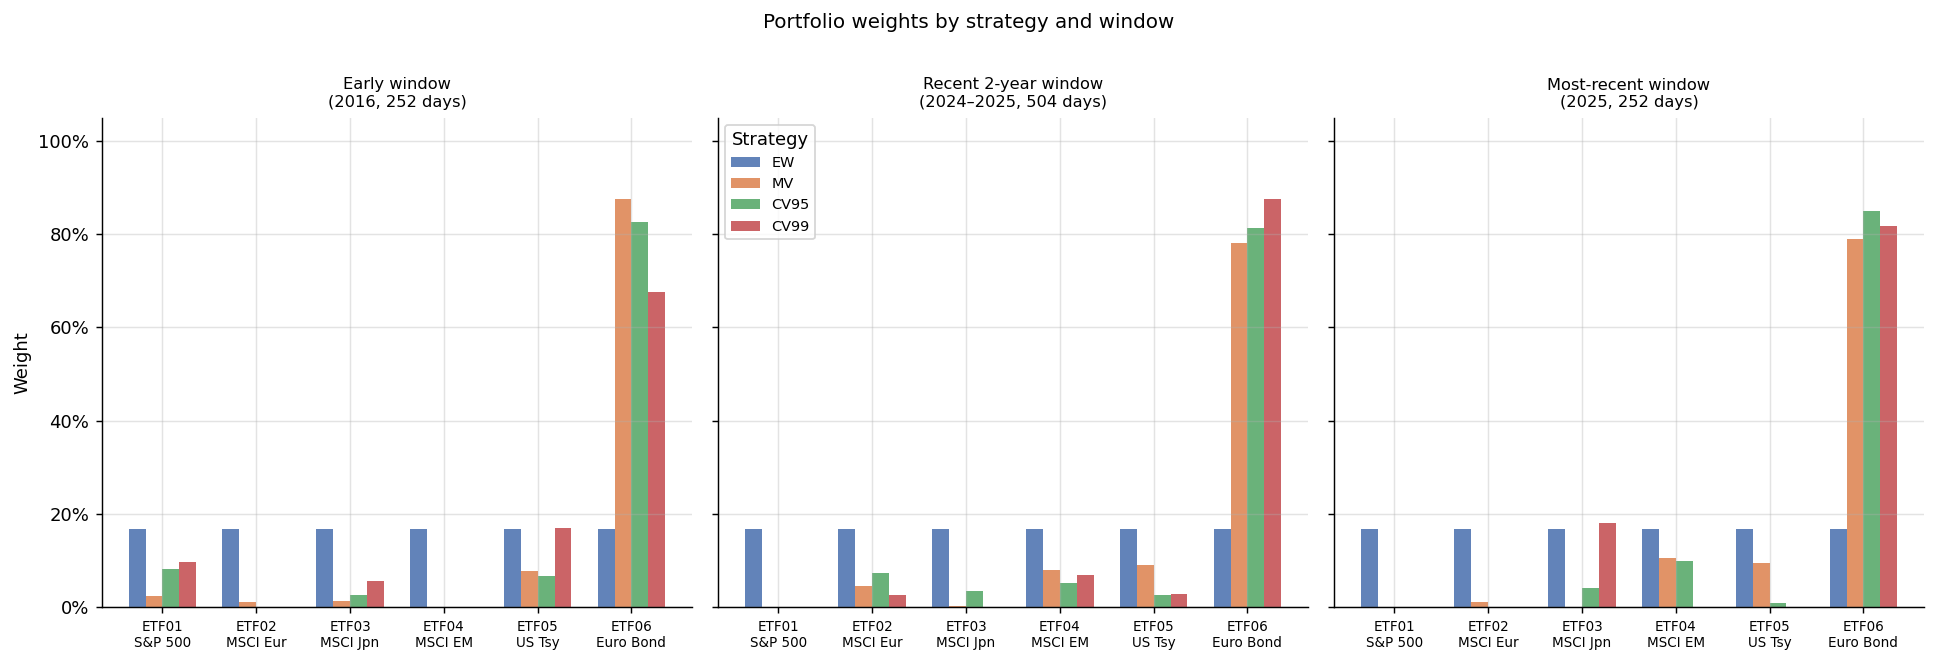

In [6]:
PLOT_WINDOWS = ["first_252", "last_504", "last_252"]
STRATEGY_ORDER = ["EW", "MV", "CV95", "CV99"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
x     = np.arange(len(ASSETS))
width = 0.18

window_titles = {
    "first_252" : "Early window\n(2016, 252 days)",
    "last_504"  : "Recent 2-year window\n(2024–2025, 504 days)",
    "last_252"  : "Most-recent window\n(2025, 252 days)",
}

for ax, wname in zip(axes, PLOT_WINDOWS):
    res = all_results[wname]
    for i, strat in enumerate(STRATEGY_ORDER):
        offsets = x + (i - 1.5) * width
        vals    = [float(res[strat][a]) for a in ASSETS]
        ax.bar(offsets, vals, width, label=strat,
               color=STRATEGY_COLORS[strat], alpha=0.88)

    ax.set_title(window_titles[wname], fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([ETF_LABELS[a] for a in ASSETS], fontsize=7.5)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[0].set_ylabel("Weight")
axes[1].legend(title="Strategy", loc="upper left", fontsize=8)

fig.suptitle(
    "Portfolio weights by strategy and window",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIGURES / "04_strategy_weights.png", bbox_inches="tight")
plt.show()

## 6 · Concentration: Effective N Across Windows

Effective N = 1/HHI.  Equal weight = 6.0 (maximum diversification for 6 assets).
Lower values indicate more concentrated portfolios.

In [7]:
eff_n_rows = []
for wname in WINDOWS:
    for strat, w in all_results[wname].items():
        eff_n_rows.append({
            "window"   : wname,
            "strategy" : strat,
            "HHI"      : round(float((w**2).sum()), 4),
            "eff_N"    : round(1.0 / float((w**2).sum()), 2),
        })

eff_n = (
    pd.DataFrame(eff_n_rows)
    .pivot(index="window", columns="strategy", values="eff_N")
    .reindex(columns=STRATEGY_ORDER)
)

window_order = ["first_252", "last_504", "last_252", "full_history"]
eff_n = eff_n.reindex(window_order)

print("Effective N (1/HHI)  — higher = more diversified, max = 6.0")
print(eff_n.to_string())

Effective N (1/HHI)  — higher = more diversified, max = 6.0
strategy       EW    MV  CV95  CV99
window                             
first_252     6.0  1.30  1.44  2.00
last_504      6.0  1.59  1.49  1.29
last_252      6.0  1.55  1.36  1.42
full_history  6.0  1.87  1.82  1.63


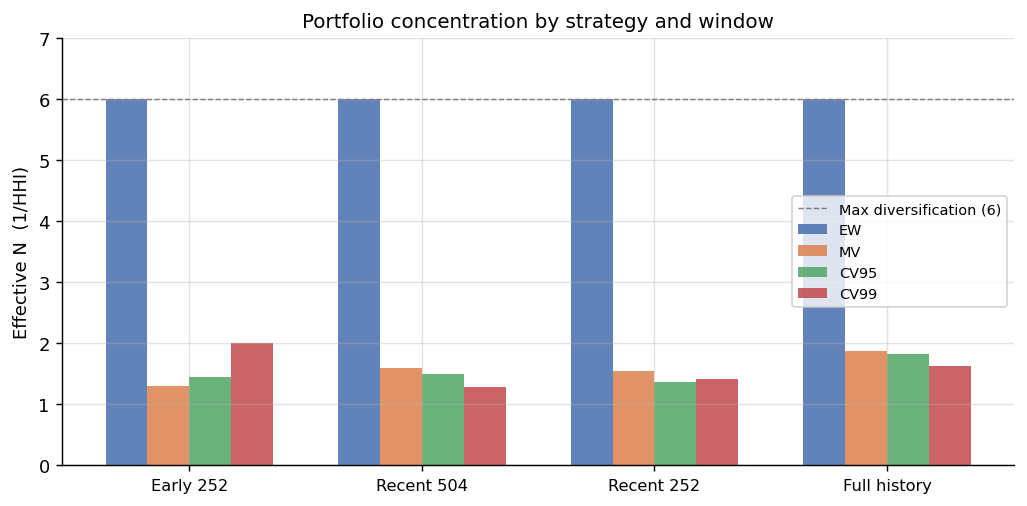

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
xw    = np.arange(len(window_order))
width = 0.18

for i, strat in enumerate(STRATEGY_ORDER):
    ax.bar(xw + (i - 1.5) * width, eff_n[strat],
           width, label=strat,
           color=STRATEGY_COLORS[strat], alpha=0.88)

ax.axhline(6, color="grey", linewidth=0.8, linestyle="--", label="Max diversification (6)")
ax.set_xticks(xw)
ax.set_xticklabels(["Early 252", "Recent 504", "Recent 252", "Full history"], fontsize=9)
ax.set_ylabel("Effective N  (1/HHI)")
ax.set_title("Portfolio concentration by strategy and window", fontsize=11)
ax.set_ylim(0, 7)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "05_effective_n.png", bbox_inches="tight")
plt.show()

## 7 · Final Constraint Validation Summary

In [9]:
all_pass = True
rows = []
for wname, res in all_results.items():
    for strat, w in res.items():
        chk  = constraint_check(w, strat)
        pass_ = (chk["sum_ok"] == "\u2713") and (chk["long_only_ok"] == "\u2713")
        if not pass_:
            all_pass = False
        rows.append({
            "window"     : wname,
            "strategy"   : strat,
            "sum"        : chk["sum"],
            "min_weight" : chk["min"],
            "max_weight" : chk["max"],
            "n_negative" : chk["n_negative"],
            "sum_ok"     : chk["sum_ok"],
            "long_only"  : chk["long_only_ok"],
            "overall"    : "\u2713 PASS" if pass_ else "\u2717 FAIL",
        })

val_df = pd.DataFrame(rows)
print(val_df.to_string(index=False))
print()
if all_pass:
    print("\u2713 All", len(rows), "strategy–window combinations passed constraints.")
else:
    print("\u2717 Some combinations FAILED. Check rows above.")

      window strategy  sum  min_weight  max_weight  n_negative sum_ok long_only overall
   first_252       EW  1.0    0.166667    0.166667           0      ✓         ✓  ✓ PASS
   first_252       MV  1.0    0.000000    0.874814           0      ✓         ✓  ✓ PASS
   first_252     CV95  1.0    0.000000    0.826919           0      ✓         ✓  ✓ PASS
   first_252     CV99  1.0    0.000000    0.677096           0      ✓         ✓  ✓ PASS
    last_504       EW  1.0    0.166667    0.166667           0      ✓         ✓  ✓ PASS
    last_504       MV  1.0    0.000000    0.781968           0      ✓         ✓  ✓ PASS
    last_504     CV95  1.0    0.000000    0.814180           0      ✓         ✓  ✓ PASS
    last_504     CV99  1.0    0.000000    0.876461           0      ✓         ✓  ✓ PASS
    last_252       EW  1.0    0.166667    0.166667           0      ✓         ✓  ✓ PASS
    last_252       MV  1.0    0.000000    0.789433           0      ✓         ✓  ✓ PASS
    last_252     CV95  1.0    0.

## 8 · Interpretation

### Equal Weight — the benchmark

EW assigns 16.7 % to each ETF regardless of risk or return characteristics.
It is the only strategy that remains stable across all windows (by design).
With an effective N of exactly 6.0 it is maximally diversified by the HHI measure.
Its weakness is that it is indifferent to the very different volatility profiles
of the ETFs: a 16.7 % weight in ETF01 (S&P 500, ~17.6 % ann. vol) contributes
roughly three times as much risk as the same weight in ETF06 (Euro Bond, ~6 % ann. vol).

### Minimum Variance — risk-aware tilt

MV systematically redirects weight toward lower-volatility assets.
Across all windows ETF06 (Euro Govt Bond) receives the dominant allocation,
often above 70 %, because it has the lowest individual variance in the universe.
ETF05 (US Treasury) picks up a secondary allocation for similar reasons.
Equity ETFs are typically zeroed out or held at token weights — their individual
volatilities are too high for a pure variance-minimising objective to justify them
in the absence of a return target or allocation floor.

The MV effective N of 1.5–2.5 reflects this concentration; it is numerically far
from equal weight. For backtesting purposes this is expected behaviour, not a bug.

### CVaR-Minimise — tail-risk focus

CVaR-0.95 and CVaR-0.99 produce qualitatively similar allocations to MV:
heavy bond tilts, near-zero equity exposure. This is expected — when the
objective is purely to minimise downside tail risk with no return constraint,
bonds dominate. The difference between the two alpha levels is subtle:
CV99 is slightly more concentrated in ETF06 because α=0.99 looks at an even
more extreme tail (the worst 1 % of days rather than worst 5 %).

Across windows, CVaR-min weights are more sensitive to the window than MV.
This is because CVaR estimation relies on the empirical tail of the sample;
a 252-day window contains only ~12 observations in the worst 5 % tail,
making the estimator noisier than the full-covariance estimate used by MV.
Larger windows (504 days, full history) produce more stable CVaR allocations.

### Plausibility check

All results are consistent with what portfolio theory would predict for this
universe:
- Risk-minimising strategies heavily favour the lowest-vol bond ETF
- Equity exposure is only present when its covariance with other assets
  provides enough diversification benefit to offset its higher individual risk
- The CVaR solver converged at OPTIMAL for all windows using CLARABEL
- All 16 weight vectors (4 strategies × 4 windows) pass the long-only and
  fully-invested constraints

These strategies are ready to be embedded in the rolling backtest.
When a minimum weight floor (e.g. 5 % per asset) is added in the backtester
the concentration will reduce and equity exposure will be non-trivial.